In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [3]:
# read in data
data_new_worth = pd.read_csv("../Data/net_worth_cleaned.csv", encoding='ISO-8859-1', index_col='observation_date', parse_dates=True)
data_unemployment = pd.read_csv("../Data/unemployment_cleaned.csv", encoding='ISO-8859-1', index_col='observation_date', parse_dates=True)

In [5]:
# align the two datasets and split into training and testing sets
data_new_worth, data_unemployment = data_new_worth.align(data_unemployment, join='inner', axis=0)
data_new_worth = data_new_worth.asfreq('QS')
data_unemployment = data_unemployment.asfreq('QS')
last_year = data_new_worth.index.year.max() # get the last year in the dataset to use as the test set
train = data_new_worth.index.year < last_year
test  = data_new_worth.index.year == last_year

# create training and testing sets for both datasets
unemployment_train = data_unemployment[train]
unemployment_test  = data_unemployment[test]

train_all = data_new_worth[train]
test_all  = data_new_worth[test]

In [6]:
# fit a linear regression model for each net worth group and evaluate the results
results = []

# loop through each net worth group and fit a linear regression model using the unemployment data as the predictor
for y_col in data_new_worth.columns:
    y_train = train_all[y_col]
    y_test  = test_all[y_col]

    # fit the linear regression model
    model = LinearRegression()
    model.fit(unemployment_train, y_train)

    # make predictions and evaluate the model
    y_pred = model.predict(unemployment_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    percent_error = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    results.append({
        'Net Worth Group': y_col,
        'RMSE': rmse,
        'R^2': r2,
        'Percent Error (%)': percent_error
    })

In [7]:
results_df = pd.DataFrame(results)
print(results_df)

  Net Worth Group          RMSE         R^2  Percent Error (%)
0   99.9% to 100%  1.354903e+07 -132.151692          46.781826
1    99% to 99.9%  2.462370e+06 -497.262308          59.391242
2     99% to 100%  2.773789e+07 -200.387380          45.162970
3      90% to 99%  2.336207e+07 -565.243052          46.667026
4      50% to 90%  2.636364e+07 -131.574719          49.959965
5       0% to 50%  1.281595e+07 -130.929682          53.817736


In [8]:
# fit an ARIMA model for each net worth group and evaluate the results
train = (data_new_worth.index.year >= 2004) & (data_new_worth.index.year <= 2024)
test = (data_new_worth.index.year >= 2025)

y_train_all = data_new_worth[train]
y_test_all  = data_new_worth[test]

X_train_all = data_unemployment[train]
X_test_all  = data_unemployment[test]

In [10]:
# fit an ARIMA model for each net worth group using the unemployment data as the exogenous variable
model_fits = {}

for y_col in y_train_all.columns:
    for x_col in X_train_all.columns:
        y_train = y_train_all[y_col].dropna()
        X_train = X_train_all[[x_col]].loc[y_train.index]
        
        try:
            model = ARIMA(y_train, exog=X_train, order=(1,1,1))
            model_fit = model.fit()
            model_fits[(y_col, x_col)] = model_fit
            print(f"Fitted: {y_col} ~ {x_col}")
        except Exception as e:
            print(f"Skipped {y_col} ~ {x_col}: {e}")

Fitted: 99.9% to 100% ~ 20-24
Fitted: 99.9% to 100% ~ 25-34
Fitted: 99.9% to 100% ~ 35-44
Fitted: 99.9% to 100% ~ 45-54
Fitted: 99.9% to 100% ~ 55 & Over
Fitted: 99% to 99.9% ~ 20-24
Fitted: 99% to 99.9% ~ 25-34
Fitted: 99% to 99.9% ~ 35-44
Fitted: 99% to 99.9% ~ 45-54
Fitted: 99% to 99.9% ~ 55 & Over
Fitted: 99% to 100% ~ 20-24
Fitted: 99% to 100% ~ 25-34
Fitted: 99% to 100% ~ 35-44
Fitted: 99% to 100% ~ 45-54
Fitted: 99% to 100% ~ 55 & Over
Fitted: 90% to 99% ~ 20-24
Fitted: 90% to 99% ~ 25-34
Fitted: 90% to 99% ~ 35-44
Fitted: 90% to 99% ~ 45-54
Fitted: 90% to 99% ~ 55 & Over
Fitted: 50% to 90% ~ 20-24
Fitted: 50% to 90% ~ 25-34
Fitted: 50% to 90% ~ 35-44
Fitted: 50% to 90% ~ 45-54
Fitted: 50% to 90% ~ 55 & Over
Fitted: 0% to 50% ~ 20-24
Fitted: 0% to 50% ~ 25-34
Fitted: 0% to 50% ~ 35-44
Fitted: 0% to 50% ~ 45-54
Fitted: 0% to 50% ~ 55 & Over


In [11]:
# make predictions using the fitted ARIMA models
predictions = {}

# loop through each fitted model and make predictions for the test set
for (y_col, x_col), model_fit in model_fits.items():
    X_test = X_test_all[[x_col]]
    try:
        forecast = model_fit.forecast(steps=len(X_test), exog=X_test)
        predictions[(y_col, x_col)] = forecast
    except Exception as e:
        print(f"Forecast failed for {y_col} ~ {x_col}: {e}")

In [19]:
rows = []

# create a DataFrame to compare the forecasts with the actual values
for (y_col, x_col), pred in predictions.items():
    for date, value in zip(pred.index, pred.values):
        rows.append({
            'Date': date,
            'Net Worth (y)': y_col,
            'Unemployment (x)': x_col,
            'Forecast': value,
            'Actual': y_test_all.loc[date, y_col]
        })

# convert the list of rows into a DataFrame for easier analysis
forecast_df = pd.DataFrame(rows)

# typecast forecast to numeric and remove scientific notation for better readability
pd.options.display.float_format = '{:.0f}'.format
forecast_df['Forecast'] = pd.to_numeric(forecast_df['Forecast'], errors='coerce')
                                        
print(forecast_df)

         Date  Net Worth (y) Unemployment (x)  Forecast    Actual
0  2025-01-01  99.9% to 100%            20-24  27581101  27062861
1  2025-04-01  99.9% to 100%            20-24  27804706  28519246
2  2025-07-01  99.9% to 100%            20-24  28030646  29938926
3  2025-01-01  99.9% to 100%            25-34  27576806  27062861
4  2025-04-01  99.9% to 100%            25-34  27795320  28519246
..        ...            ...              ...       ...       ...
85 2025-04-01      0% to 50%            45-54  22901779  23464241
86 2025-07-01      0% to 50%            45-54  23102915  24887247
87 2025-01-01      0% to 50%        55 & Over  22686695  22154938
88 2025-04-01      0% to 50%        55 & Over  22893423  23464241
89 2025-07-01      0% to 50%        55 & Over  23097688  24887247

[90 rows x 5 columns]


In [22]:
results = []

# evaluate the predictions by calculating RMSE, R^2, and percent error for each net worth group and unemployment predictor
for (y_col, x_col), pred in predictions.items():
    actual = y_test_all[y_col].loc[pred.index]
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    percent_error = np.mean(np.abs((actual - pred) / actual)) * 100
    results.append({
        'Net Worth (y)': y_col,
        'Unemployment (x)': x_col,
        'RMSE': rmse,
        'R^2': r2,
        'Percent Error (%)': percent_error
    })

# convert the results into a DataFrame for better visualization
pd.options.display.float_format = '{:.3f}'.format
results_df = pd.DataFrame(results)
print(results_df)

    Net Worth (y) Unemployment (x)        RMSE    R^2  Percent Error (%)
0   99.9% to 100%            20-24 1213901.869 -0.069              3.598
1   99.9% to 100%            25-34 1216761.476 -0.074              3.607
2   99.9% to 100%            35-44 1220435.984 -0.080              3.609
3   99.9% to 100%            45-54 1212626.651 -0.067              3.593
4   99.9% to 100%        55 & Over 1217246.331 -0.075              3.604
5    99% to 99.9%            20-24  128464.656 -0.356              2.653
6    99% to 99.9%            25-34  128710.172 -0.361              2.657
7    99% to 99.9%            35-44  128754.974 -0.362              2.655
8    99% to 99.9%            45-54  128534.001 -0.358              2.654
9    99% to 99.9%        55 & Over  128372.434 -0.354              2.650
10    99% to 100%            20-24 1919707.651  0.035              2.733
11    99% to 100%            25-34 1920652.346  0.034              2.735
12    99% to 100%            35-44 1925034.095  0.0

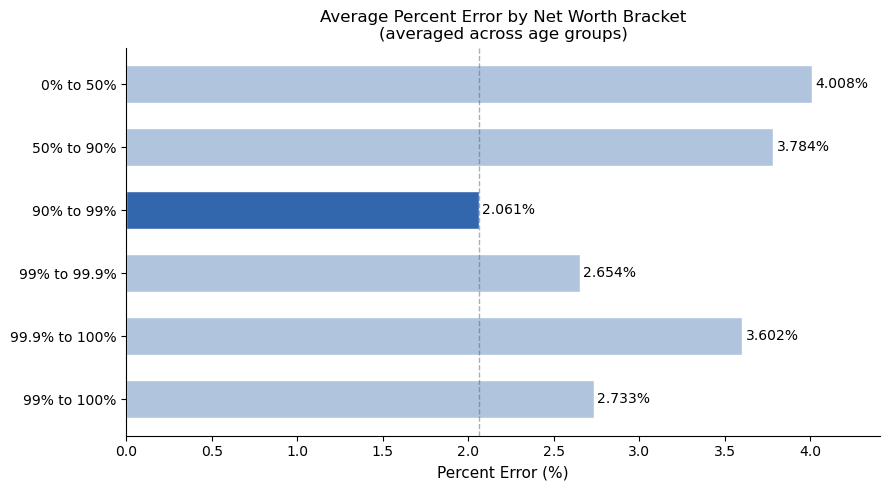

In [24]:
# visualize the average percent error by net worth bracket

# create brackets
from matplotlib import colors


brackets = [
    "0% to 50%",
    "50% to 90%",
    "90% to 99%",
    "99% to 99.9%",
    "99.9% to 100%",
    "99% to 100%"
]

# Average percent error across all age groups per bracket
# DONE WITH AI to get averages
pct_errors = [
    (4.011 + 4.011 + 4.012 + 3.998 + 4.008) / 5,  # 0–50%
    (3.782 + 3.789 + 3.791 + 3.776 + 3.782) / 5,  # 50–90%
    (2.062 + 2.058 + 2.065 + 2.059 + 2.063) / 5,  # 90–99%
    (2.653 + 2.657 + 2.655 + 2.654 + 2.650) / 5,  # 99–99.9%
    (3.598 + 3.607 + 3.609 + 3.593 + 3.604) / 5,  # 99.9–100%
    (2.733 + 2.735 + 2.736 + 2.728 + 2.734) / 5,  # 99–100%
]

colors = ["#3266ad" if v == min(pct_errors) else "#b0c4de" for v in pct_errors]

# create a horizontal bar chart to visualize the percent errors by bracket
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(brackets, pct_errors, color=colors, edgecolor="white", height=0.6)

# add percent error labels to the bars
for bar, val in zip(bars, pct_errors):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}%", va="center", fontsize=10)

# label plot and customize axes
ax.set_xlabel("Percent Error (%)", fontsize=11)
ax.set_title("Average Percent Error by Net Worth Bracket\n(averaged across age groups)", fontsize=12)
ax.set_xlim(0, max(pct_errors) + 0.4)
ax.axvline(min(pct_errors), color="#3266ad", linestyle="--", linewidth=1, alpha=0.5)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

# plot the figure
plt.tight_layout()
plt.savefig("percent_error_by_bracket.png", dpi=150)
plt.show()

Age group has little effect on net worth bracket. % error spreads were +/- 0.1%